# Test the statistical method for different scenario

In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt
c0 ={'acc':'#941717', 'cor':'#388E3C','ggd':'#42A5F5', 'wd':'#FFA000', 'sum':'lightgrey'}
plt.rcParams["hatch.linewidth"] = 8
from diagnosis import compute_mean_square
from cstes import U

images_dir = '/Users/mdemol/ownCloud/PhD/images/images_methodo'

In [2]:
N=100000 # nb coloc

__________________________
# 1. No errors
## 1.1. Gradient wind balance

$$u_{\theta} = -\frac{1}{2}fr \pm \frac{1}{2}fr\sqrt{1+\frac{4}{fr}u_g} $$

$$\frac{u_{\theta}^2}{r} + fu_{\theta} = g\partial_r\eta = fu_g$$

$$ \frac{4u_g}{fr}>-1 $$

$$u_g = \frac{fr}{4}[(\frac{2u_{\theta}}{fr}-1)^2-1]$$

In [3]:
def compute_u_theta(f, r, ug):
    a = -1/2*f*r 
    b = 1/2*f*r*np.sqrt(1+4*ug/f/r)
    return a-b, a+b
def compute_ug(f, r, utheta):
    return f*r/4*((2*utheta/f/r+1)**2-1)

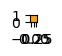

In [21]:
import numpy as np
# define normalized 2D gaussian
def gaus2d(x=0, y=0, mx=0, my=0, sx=1, sy=1):
    return 1. / (2. * np.pi * sx * sy) * np.exp(-((x - mx)**2. / (2. * sx**2.) + (y - my)**2. / (2. * sy**2.)))

def create_champ(L = 30e3, std=30e3, lat=40, dsl_amp=-3e-2):
    g=9.81
    x = np.arange(-L, L, 1e3)
    y = np.arange(-L, L, 1e3)

    X, Y = np.meshgrid(x, y) # get 2D variables instead of 1D
    z = gaus2d(X, Y, mx=0, my=0, sx=std, sy=std)
    z = z/z.max()*dsl_amp


    ds = xr.Dataset(
        data_vars=dict(
            eta=(["y","x"], z),
        ), 
        coords=dict( y=("y", y), x=("x", x),
                   ))

    ds['eta'] = ds['eta'].assign_attrs({'long_name':r'DSL $\eta$', 'unit':'m'})
    ds['x'] = ds['x'].assign_attrs({'unit':'m'})
    ds['y'] = ds['y'].assign_attrs({'unit':'m'})

    f = 2 * 2 * np.pi / 86164.1 * np.sin(lat * np.pi / 180)
    ds['r'] = np.sqrt(ds.x**2+ds.y**2)
    ds['cos'] = (ds.x/ds.r)
    ds['sin'] = (ds.y/ds.r)

    ds['dxeta'] = ds['eta'].differentiate('x')
    ds['dyeta'] = ds['eta'].differentiate('y')
    ds['dreta'] = ds.dxeta*ds.cos + ds.dyeta*ds.sin

    ds['ugx'] = g/f*ds.dyeta
    ds['ugy'] = -g/f*ds.dxeta
    ds['ug'] = g/f*ds.dreta

    def compute_u_theta(f, r, ug):
        a = -1/2*f*r 
        b = 1/2*f*r*np.sqrt(1+4*ug/f/r)
        return a-b, a+b
    
    ds['utheta0'] = compute_u_theta(f, ds.r, ds.ug)[0]
    ds['utheta1'] = compute_u_theta(f, ds.r, ds.ug)[1]
    ds['utheta1x'] = -ds.utheta1*(ds.sin)
    ds['utheta1y'] = ds.utheta1*(ds.cos)
    ds = ds.transpose('y','x')

    ds['acc'] = ds.utheta1**2/ds.r
    ds['cor'] = f*ds.utheta1
    ds['ggd'] = -g*ds.dreta
    
    ds['accx'] = ds.acc*(ds.cos)
    ds['accy'] = ds.acc*(ds.sin)
    ds['corx'] = ds.cor*(ds.cos)
    ds['cory'] = ds.cor*(ds.sin)
    ds['ggdx'] = ds.ggd*(ds.cos)
    ds['ggdy'] = ds.ggd*(ds.sin)
    #ds['corx'] = - f*ds.utheta1y
    #ds['cory'] = f*ds.utheta1x
    #ds['ggdx'] = -g*ds.dxeta
    #ds['ggdy'] = -g*ds.dyeta

    return ds


from diagnosis import compute_mean_square, put_fig_letter
from cstes import U2


def create_prod_exc_sum(df, null_mean):
    df = df.copy()
    ds = xr.Dataset()
    for direction in ['x', 'y'] : 
            if direction == 'x' : l = {'acc':'accx', 'cor':'corx', 'ggd':'ggdx', 'wd':'wdx'}
            if direction == 'y' : l = {'acc':'accy', 'cor':'cory', 'ggd':'ggdy', 'wd':'wdy'}

            if null_mean : 
                for v in l:
                    df[l[v]] = df[l[v]] - df[l[v]].mean()
            
            # sum 
            ds['sum'+direction] = sum([df[l[v]] for v in l])

            # simple var + sum- one term
            for v in l :
                ds[l[v]] = df[l[v]]
                print(df[l[v]].mean()) 
                ds['exc'+direction+'_'+v] = ds['sum'+direction]-ds[l[v]]
                
            #2 by 2 product    
            import itertools  
            couple = list(itertools.combinations(list(l.keys()),2))
            for c in couple : 
                ds['prod'+direction+'_'+'_'.join(c)] = ds[c[0]+direction] * ds[c[1]+direction]
    return ds

def plot_diag(fig, ax, ds2):
    #labels = {'acc':r'$u_{\theta}^2/r$', 'cor':r'$fu_{\theta}$', 'ggd':r'$-g\partial_r\eta$', 'wd':'Wind term','sum':'Residual'}
    #labels = {'acc':r'$d_t\vec{u}$', 'cor':r'$f\vec{k}\wedge u_{\theta}$', 'ggd':r'$-g\partial_r\eta$', 'wd':'Wind term','sum':'Residual'}
    labels = {'acc':'Lagrangian acceleration', 'cor':'Coriolis acceleration', 'ggd':'Pressure gradient term', 'wd':'Wind term','sum':'Residual'}
    plt.rcParams["axes.edgecolor"] = "k"
    df = ds.to_dataframe()
    var = ['acc', 'cor', 'ggd']
    i=0
    for v in var:
        # total MS
        #ax.bar(i, ds2[v.upper()], color=c0[v], alpha=0.5)
        w = 0.8
        #B and E
        if ds2['B_'+v] > 0 : 
            ax.bar(i, ds2['B_'+v], color=c0[v], width=w, label=labels[v])
            if ds2['E_'+v]< 0 : ax.bar(i, ds2['E_'+v], color='lightgrey', width=w)
            else : ax.bar(i, ds2['E_'+v],bottom = ds2['B_'+v], color='lightgrey', width=w)
        else :
            ax.bar(i, ds2['B_'+v], color=c0[v], width=w)
            if ds2['E_'+v]>0 : ax.bar(i, ds2['E_'+v], color='lightgrey', width=w)
            else : ax.bar(i, ds2['E_'+v],bottom = ds2['B_'+v], color='lightgrey', width=w)
                
        #X
        w=0.4
        X_var = [x for x in ds2 if (('X_' in x)&(v in x)&('ser_' not in x))]
        pos_X = [ x for x in X_var if ds2[x]>0]
        neg_X = [ x for x in X_var if x not in pos_X]
    
        sum_posX = 0
        for X in pos_X :
            xc =X.replace('X_', '').split('_')
            plt.rcParams["hatch.color"] = c0[xc[0]]
            ax.bar(i, ds2[X]/2, bottom = sum_posX, color = c0[xc[1]], hatch="/", width=w)
            sum_posX += ds2[X]/2
    
        sum_negX = 0
        for X in neg_X :
            xc =X.replace('X_', '').split('_')
            plt.rcParams["hatch.color"] = c0[xc[0]]
            ax.bar(i, ds2[X]/2, bottom = sum_negX, color = c0[xc[1]], hatch="/", width=w)
            sum_negX += ds2[X]/2
        i+=1
    #ax.bar(i, ds2['S'], color = 'lightgrey')
    ax.grid()
    #ax.legend()
    ax.set_ylabel(r'[$\gamma^2$]')

fig, ax=plt.subplots(figsize=(0.1, 0.1))
ax.bar(0,1, color=c0['acc'], label='Lagrangian acceleration')
ax.bar(0,1, color=c0['cor'], label='Coriolis acceleration')
ax.bar(0,1, color=c0['ggd'], label='Pressure gradient term')
ax.bar(0,1, color=c0['wd'], label='Wind term')
#ax.bar(0,1, color='lightgrey', label='Residual contribution')

handles, labels = ax.get_legend_handles_labels()

_____________________
# Anticyclonic eddy

7.043933033299795e-24
1.408786606659959e-22
1.408786606659959e-23
0.0
3.521966516649898e-24
2.817573213319918e-23
1.1270292853279672e-22
0.0


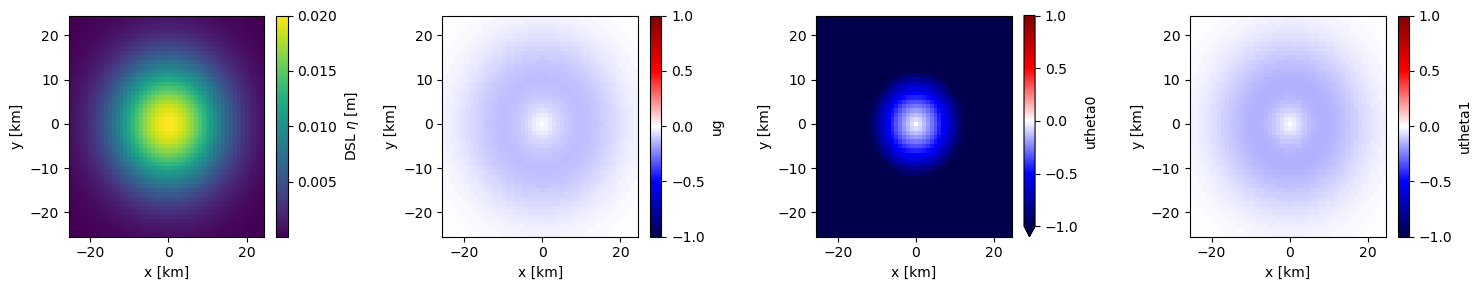

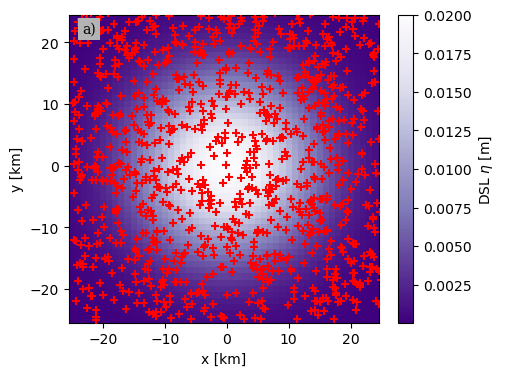

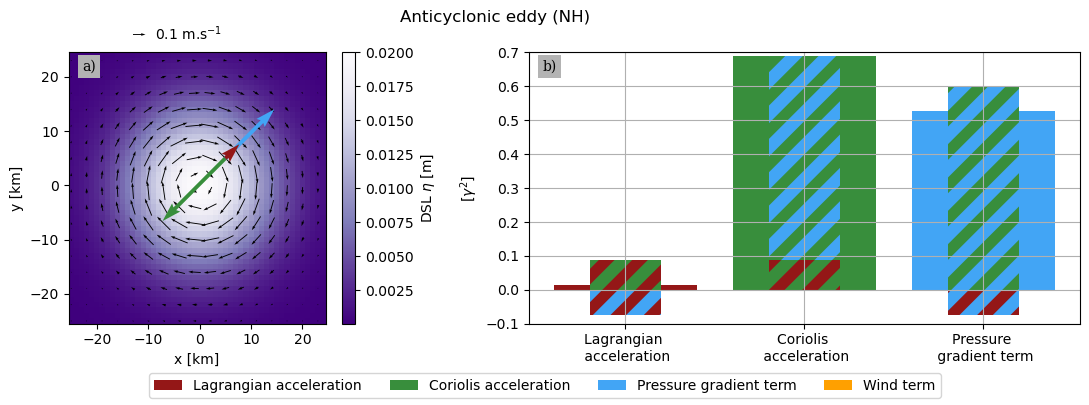

In [35]:
# Create eddy
L=25e3
std=10e3
ds = create_champ(L,std, dsl_amp=2e-2)

# Coloc 
xa = np.random.uniform(-1, 1,1000)*L
ya = np.random.uniform(-1, 1,1000)*L
dsa = ds.interp(x=('row_number', xa), y=('row_number', ya))

ds['x'] = (ds.x/1000).assign_attrs({'units':'km'})
ds['y'] = (ds.y/1000).assign_attrs({'units':'km'})
dsa['x'] = (dsa.x/1000).assign_attrs({'units':'km'})
dsa['y'] = (dsa.y/1000).assign_attrs({'units':'km'})

dsa['wdx'] = dsa['acc']/dsa['acc']-1
dsa['wdy'] = dsa['acc']/dsa['acc']-1

#check for sampling
#dsa=dsa.where(dsa.y>0, drop=True)

dfa =dsa.to_dataframe()
dsa_ = create_prod_exc_sum(dfa, null_mean = True)
#dsa__ = create_prod_exc_sum(dfa, null_mean =False)

# Reconstruction dataset
dsm = compute_mean_square(dsa_, dirname = ('x', 'y'))/U2

#FIGURES
kwargs = {'vmin':-1, 'vmax':1, 'cmap':'seismic'}
fig, axs = plt.subplots(1,4, frameon=False, figsize=(15, 3))
ds.eta.plot(ax=axs[0])
ds.ug.plot(ax=axs[1], **kwargs)
ds.utheta0.plot(ax=axs[2], **kwargs)
ds.utheta1.plot(ax=axs[3], **kwargs)
fig.tight_layout()


fig, ax = plt.subplots(1,1, frameon=False, figsize=(5, 4))
ds.eta.plot(ax=ax, cmap='Purples_r')
#a = ds.isel(x=slice(0, -1, 3), y=slice(0, -1, 3)).plot.quiver(x='x', y='y', u='utheta1x', v='utheta1y', ax=ax, add_guide= False)
#ax.quiverkey(a, 0.15, 0.9, 0.1, r'0.1 m.s$^{-1}$', coordinates='figure', labelpos='E', color = 'k')
put_fig_letter(fig, ax, 'a')
#kwargs={'pivot':'tail', 'scale':6e-5, 'add_guide':False}
#a = ds.isel(x=30, y=30).plot.quiver(x='x', y='y', u='corx', v='cory', ax=ax, color=c0['cor'], **kwargs)
#a = ds.isel(x=30, y=30).plot.quiver(x='x', y='y', u='ggdx', v='ggdy', ax=ax, color=c0['ggd'], **kwargs)
#a = ds.isel(x=30, y=30).plot.quiver(x='x', y='y', u='accx', v='accy', ax=ax, color=c0['acc'], **kwargs)
dsa.plot.scatter(x='x', y='y', marker = '+', color='r', ax=ax, zorder=10)
ax.set_title('')

#fig, axs = plt.subplots(1,1, frameon=False, figsize=(5, 4))
#ds.eta.plot(ax=axs, cmap='Blues_r')
#a = ds.isel(x=slice(0, -1, 3), y=slice(0, -1, 3)).plot.quiver(x='x', y='y', u='utheta1x', v='utheta1y', ax=axs)
#kwargs={'pivot':'tail', 'scale':3e-5}

#a = ds.isel(x=30, y=30).plot.quiver(x='x', y='y', u='corx', v='cory', ax=axs, color=c0['cor'], **kwargs)
#a = ds.isel(x=30, y=30).plot.quiver(x='x', y='y', u='ggdx', v='ggdy', ax=axs, color=c0['ggd'], **kwargs)
#a = ds.isel(x=30, y=30).plot.quiver(x='x', y='y', u='accx', v='accy', ax=axs, color=c0['acc'], **kwargs)
#fig.tight_layout()

####################################
from matplotlib.gridspec import GridSpec
fig = plt.figure( frameon=False, figsize = (10, 4))
gs = GridSpec(1, 5, figure=fig)

# Visualize row series
i=0
ax = fig.add_subplot(gs[0, :2])
ds.eta.plot(ax=ax, cmap='Purples_r')
a = ds.isel(x=slice(0, -1, 3), y=slice(0, -1, 3)).plot.quiver(x='x', y='y', u='utheta1x', v='utheta1y', ax=ax, add_guide= False)
ax.quiverkey(a, 0.15, 0.92, 0.1, r'0.1 m.s$^{-1}$', coordinates='figure', labelpos='E', color = 'k')
put_fig_letter(fig, ax, 'a')
kwargs={'pivot':'tail', 'scale':4e-5, 'add_guide':False, 'width':0.015}
a = ds.isel(x=30, y=30).plot.quiver(x='x', y='y', u='corx', v='cory', ax=ax, color=c0['cor'], **kwargs)
a = ds.isel(x=30, y=30).plot.quiver(x='x', y='y', u='ggdx', v='ggdy', ax=ax, color=c0['ggd'], **kwargs)
a = ds.isel(x=30, y=30).plot.quiver(x='x', y='y', u='accx', v='accy', ax=ax, color=c0['acc'], **kwargs)
ax.set_title('')

# Reconstruction data
ax = fig.add_subplot(gs[0, 2:])
plot_diag(fig, ax, dsm)
#ax.set_xticks(ticks = np.arange(5),labels = [r'$u_{\theta}^2/r$', r'$fu_{\theta}$', r'$-g\partial_r\eta$', 'Wind term','Residual'] )
ax.set_xticks(ticks = np.arange(3),labels =['Lagrangian \n acceleration', 'Coriolis \n acceleration', 'Pressure \n gradient term'])
fig.suptitle('Anticyclonic eddy (NH)')
fig.legend(handles, labels, ncol=4, loc="lower center")
put_fig_letter(fig, ax, 'b')

ax.set_ylim(-0.1, 0.7)
fig.tight_layout(rect=[0, 0.05, 1.1, 1])
fig.savefig(images_dir+'/anticyclonic.png')


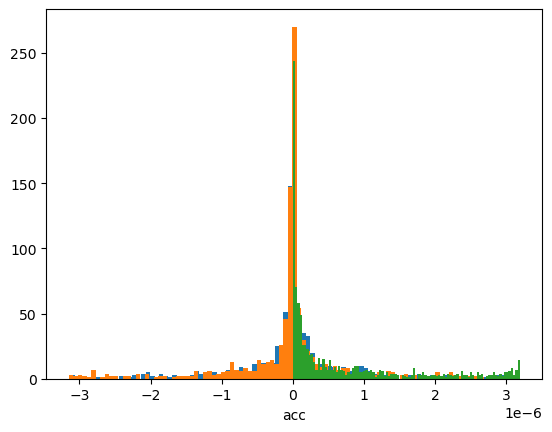

In [137]:
a=dsa.accx.plot.hist(bins=100)
a=dsa.accy.plot.hist(bins=100)
a=dsa.acc.plot.hist(bins=100)

In [138]:
-2*(dsa.acc*dsa.ggd).mean('row_number')/U2, -2*(dsa.acc*dsa.cor).mean('row_number')/U2, -2*(dsa.cor*dsa.ggd).mean('row_number')/U2

(<xarray.DataArray ()> Size: 8B
 array(-0.14440142),
 <xarray.DataArray ()> Size: 8B
 array(0.17291782),
 <xarray.DataArray ()> Size: 8B
 array(1.19020396))

_____________________
# Cyclonic eddy

-5.771188843975841e-24
-9.944202315773757e-23
1.4206003308248224e-23
0.0
7.990876860889626e-24
3.551500827062056e-23
-4.2618009924744673e-23
0.0
1.817141949314156e-08
2.276326926571131e-07
-2.458041121502547e-07
0.0
-2.027397546970723e-09
-9.025605618624698e-08
9.228345373321767e-08
0.0


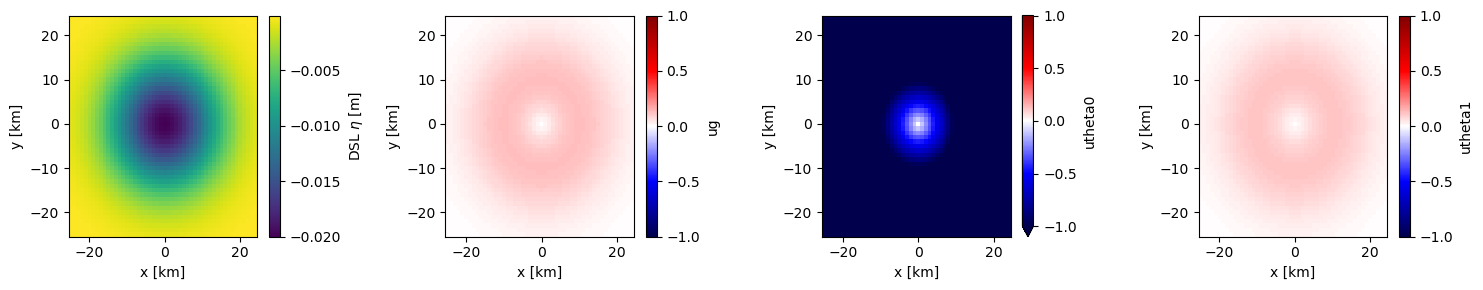

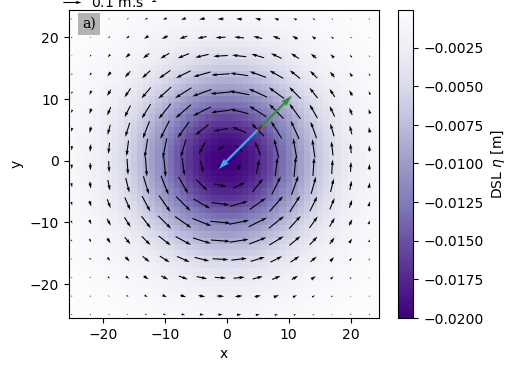

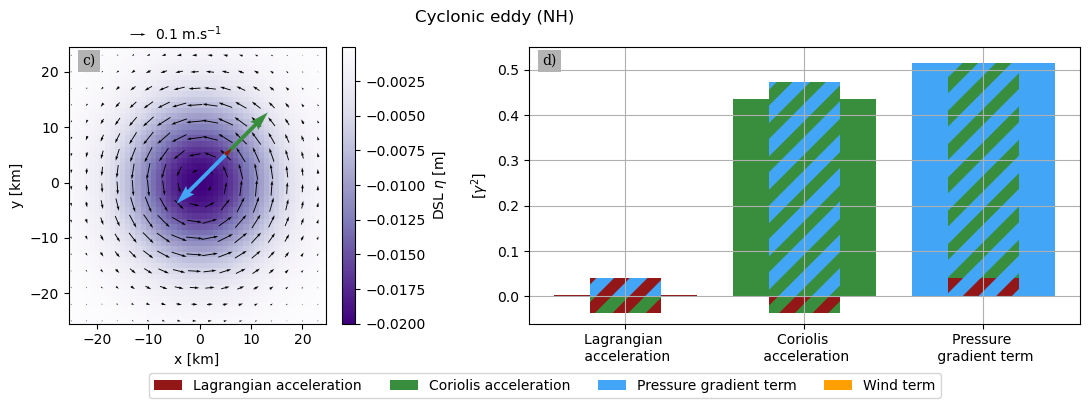

In [30]:
# Create eddy
L=25e3
std=10e3
ds = create_champ(L,std, dsl_amp=-2e-2)

#Coloc
xa = np.random.uniform(-1, 1,1000)*L
ya = np.random.uniform(-1, 1,1000)*L
dsa = ds.interp(x=('row_number', xa), y=('row_number', ya))

ds['x'] = (ds.x/1000).assign_attrs({'units':'km'})
ds['y'] = (ds.y/1000).assign_attrs({'units':'km'})

dsa['wdx'] = dsa['acc']/dsa['acc']-1
dsa['wdy'] = dsa['acc']/dsa['acc']-1

dfa =dsa.to_dataframe()
dsa_ = create_prod_exc_sum(dfa, null_mean = True)
dsa__ = create_prod_exc_sum(dfa, null_mean =False)

# Reconstruction dataset
dsm = compute_mean_square(dsa_, dirname = ('x', 'y'))/U2

#FIGURES
kwargs = {'vmin':-1, 'vmax':1, 'cmap':'seismic'}
fig, axs = plt.subplots(1,4, frameon=False, figsize=(15, 3))
ds.eta.plot(ax=axs[0])
ds.ug.plot(ax=axs[1], **kwargs)
ds.utheta0.plot(ax=axs[2], **kwargs)
ds.utheta1.plot(ax=axs[3], **kwargs)
fig.tight_layout()


fig, ax = plt.subplots(1,1, frameon=False, figsize=(5, 4))
ds.eta.plot(ax=ax, cmap='Purples_r')
a = ds.isel(x=slice(0, -1, 3), y=slice(0, -1, 3)).plot.quiver(x='x', y='y', u='utheta1x', v='utheta1y', ax=ax, add_guide= False)
ax.quiverkey(a, 0.15, 0.9, 0.1, r'0.1 m.s$^{-1}$', coordinates='figure', labelpos='E', color = 'k')
put_fig_letter(fig, ax, 'a')
kwargs={'pivot':'tail', 'scale':6e-5, 'add_guide':False}
a = ds.isel(x=30, y=30).plot.quiver(x='x', y='y', u='corx', v='cory', ax=ax, color=c0['cor'], **kwargs)
a = ds.isel(x=30, y=30).plot.quiver(x='x', y='y', u='ggdx', v='ggdy', ax=ax, color=c0['ggd'], **kwargs)
a = ds.isel(x=30, y=30).plot.quiver(x='x', y='y', u='accx', v='accy', ax=ax, color=c0['acc'], **kwargs)
ax.set_title('')

dsa.plot.scatter(x='x', y='y', marker = '+', color='k')

#fig, axs = plt.subplots(1,1, frameon=False, figsize=(5, 4))
#ds.eta.plot(ax=axs, cmap='Blues_r')
#a = ds.isel(x=slice(0, -1, 3), y=slice(0, -1, 3)).plot.quiver(x='x', y='y', u='utheta1x', v='utheta1y', ax=axs)
#kwargs={'pivot':'tail', 'scale':3e-5}

#a = ds.isel(x=30, y=30).plot.quiver(x='x', y='y', u='corx', v='cory', ax=axs, color=c0['cor'], **kwargs)
#a = ds.isel(x=30, y=30).plot.quiver(x='x', y='y', u='ggdx', v='ggdy', ax=axs, color=c0['ggd'], **kwargs)
#a = ds.isel(x=30, y=30).plot.quiver(x='x', y='y', u='accx', v='accy', ax=axs, color=c0['acc'], **kwargs)
#fig.tight_layout()

####################################

from matplotlib.gridspec import GridSpec
fig = plt.figure( frameon=False, figsize = (10, 4))
gs = GridSpec(1, 5, figure=fig)

# Visualize row series
i=0
ax = fig.add_subplot(gs[0, :2])
ds.eta.plot(ax=ax, cmap='Purples_r')
a = ds.isel(x=slice(0, -1, 3), y=slice(0, -1, 3)).plot.quiver(x='x', y='y', u='utheta1x', v='utheta1y', ax=ax, add_guide= False)
ax.quiverkey(a, 0.15, 0.92, 0.1, r'0.1 m.s$^{-1}$', coordinates='figure', labelpos='E', color = 'k')
put_fig_letter(fig, ax, 'c')
kwargs={'pivot':'tail', 'scale':4e-5, 'add_guide':False, 'width':0.015}
a = ds.isel(x=30, y=30).plot.quiver(x='x', y='y', u='corx', v='cory', ax=ax, color=c0['cor'], **kwargs)
a = ds.isel(x=30, y=30).plot.quiver(x='x', y='y', u='ggdx', v='ggdy', ax=ax, color=c0['ggd'], **kwargs)
a = ds.isel(x=30, y=30).plot.quiver(x='x', y='y', u='accx', v='accy', ax=ax, color=c0['acc'], **kwargs)
ax.set_title('')

# Reconstruction data
ax = fig.add_subplot(gs[0, 2:])
plot_diag(fig, ax, dsm)
#ax.set_xticks(ticks = np.arange(5),labels = [r'$u_{\theta}^2/r$', r'$fu_{\theta}$', r'$-g\partial_r\eta$', 'Wind term','Residual'] )
ax.set_xticks(ticks = np.arange(3),labels =['Lagrangian \n acceleration', 'Coriolis \n acceleration', 'Pressure \n gradient term'])
fig.suptitle('Cyclonic eddy (NH)')
fig.legend(handles, labels, ncol=4, loc="lower center")
put_fig_letter(fig, ax, 'd')

ax.set_ylim(-0.06, 0.55)
fig.tight_layout(rect=[0, 0.05, 1.1, 1])

fig.savefig(images_dir+'/cyclonic.png')